# Conformal Uncertainty for Koopman Forecasts

This notebook adds **distribution-free conformal prediction**
(`ConformalKoopmanUQ`) to the uncertainty story from
[`21_uncertainty_quantification.ipynb`](21_uncertainty_quantification.ipynb).
You will calibrate split conformal bands at several miscoverage levels α,
compare coverage and sharpness to ensemble and latent-Gaussian intervals, and
see when **adaptive conformal inference (ACI)** recovers coverage under an
injected residual drift.

**Prerequisites.** Encode → Koopman step → decode from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb); ensemble / latent-
Gaussian protocol from notebook 21.


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets import SyntheticDynamicGraphBenchmark
from koopman_graph.uq import (
    ConformalKoopmanUQ,
    EnsembleGraphKoopmanModel,
    LatentGaussianKoopmanUQ,
    empirical_coverage,
)
from koopman_graph.uq.common import snapshot_with_features

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 30
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

NUM_NODES = 6 if IS_TEST else 8
# Longer series → enough calibration windows so α changes the split order statistic.
NUM_TIMESTEPS = 48 if IS_TEST else 96
IN_CHANNELS = 1
HIDDEN = 16 if IS_TEST else 32
LATENT = 8 if IS_TEST else 16
EPOCHS = 2 if IS_TEST else 40
N_MEMBERS = 2 if IS_TEST else 5
HORIZON = 2 if IS_TEST else 6
ALPHAS = (0.2,) if IS_TEST else (0.05, 0.1, 0.2)
N_SAMPLES = 16 if IS_TEST else 64
TRAIN_FRAC = 0.45 if IS_TEST else 0.50
CAL_FRAC = 0.40 if IS_TEST else 0.35
# Remainder is the test / holdout window.

print(f"koopman_graph {koopman_graph.__version__}")
print(f"IS_TEST={IS_TEST}  EPOCHS={EPOCHS}  HORIZON={HORIZON}  ALPHAS={ALPHAS}")


koopman_graph 0.10.0
IS_TEST=False  EPOCHS=40  HORIZON=6  ALPHAS=(0.05, 0.1, 0.2)


### Helpers and chronological splits

Helper constructors stay in Setup so the narrative cells stay short. The
synthetic ring graph is split **train → calibrate → test** in time so conformal
calibration never touches the final holdout.


In [2]:
def make_member() -> GraphKoopmanModel:
    return GraphKoopmanModel(
        encoder=GNNEncoder(IN_CHANNELS, HIDDEN, LATENT, num_layers=2),
        decoder=GNNDecoder(LATENT, HIDDEN, IN_CHANNELS, num_layers=2),
        latent_dim=LATENT,
        time_step=1.0,
        dynamics_mode="discrete",
        koopman="graph",
    )


def calibration_windows(
    sequence: GraphSnapshotSequence,
    *,
    steps: int,
    stride: int = 1,
) -> list[GraphSnapshotSequence]:
    # Each window is [origin, target_1, ..., target_steps].
    windows: list[GraphSnapshotSequence] = []
    last_start = sequence.num_timesteps - steps - 1
    for start in range(0, last_start + 1, stride):
        snaps = [sequence[start + offset] for offset in range(steps + 1)]
        windows.append(GraphSnapshotSequence(snaps))
    return windows


def mean_interval_width(interval) -> float:
    widths = [
        float((hi.x - lo.x).mean().item())
        for lo, hi in zip(interval.lower, interval.upper, strict=True)
    ]
    return float(np.mean(widths))


def patch_zero_predict(model: GraphKoopmanModel) -> None:
    # Teaching drift demo: predict always returns zeros (known residual = target).

    def _predict(
        initial_graph,
        steps,
        edge_index=None,
        edge_weight=None,
        controls=None,
        future_topologies=None,
        history=None,
    ):
        del edge_weight, controls, future_topologies, history
        if isinstance(initial_graph, Data):
            template = initial_graph
            assert template.x is not None
            zeros = torch.zeros_like(template.x)
        else:
            template = Data(x=initial_graph, edge_index=edge_index)
            zeros = torch.zeros_like(initial_graph)
        return [snapshot_with_features(template, zeros) for _ in range(steps)]

    model.predict = _predict  # type: ignore[method-assign]


def constant_residual_sequence(
    *,
    residual: float,
    steps: int,
    edge_index: torch.Tensor,
) -> GraphSnapshotSequence:
    num_nodes = int(edge_index.max().item()) + 1
    origin = Data(
        x=torch.zeros(num_nodes, IN_CHANNELS),
        edge_index=edge_index,
    )
    snaps = [origin]
    for _ in range(steps):
        snaps.append(
            Data(
                x=torch.full((num_nodes, IN_CHANNELS), residual),
                edge_index=edge_index,
            )
        )
    return GraphSnapshotSequence(snaps)


sequence = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=NUM_NODES,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    topology="ring",
    noise_std=0.04,
    seed=SEED,
)
n_train = max(HORIZON + 4, int(TRAIN_FRAC * NUM_TIMESTEPS))
n_cal = max(HORIZON + 3, int(CAL_FRAC * NUM_TIMESTEPS))
n_test = NUM_TIMESTEPS - n_train - n_cal
assert n_test >= HORIZON + 1

train = sequence.slice(0, n_train)
cal = sequence.slice(n_train, n_train + n_cal)
test = sequence.slice(n_train + n_cal, NUM_TIMESTEPS)
cal_windows = calibration_windows(cal, steps=HORIZON, stride=1)
print(
    f"T_train={train.num_timesteps}  T_cal={cal.num_timesteps}  "
    f"T_test={test.num_timesteps}  cal_windows={len(cal_windows)}"
)


T_train=48  T_cal=33  T_test=15  cal_windows=27


## Motivation and background

Ensemble and latent-Gaussian UQ (notebook 21) — and related probabilistic
Koopman forecasters such as \(K^2\)VAE (Wu et al., 2025) — produce useful
**heuristic** bands. Split conformal prediction instead wraps a fitted model
with a calibration set of nonconformity scores and returns bands with
**marginal coverage** \(1-\alpha\) under **exchangeability** of those scores
(Lei et al., 2018; foundations in Vovk et al., 2005). Multi-step graph forecasts
typically violate exchangeability — treat reported coverage as empirical, not an
exact guarantee.

Adaptive conformal inference (ACI; Gibbs & Candès, NeurIPS 2021) updates the
quantile online during the calibration stream and is more robust when residuals
drift. Conformal Koopman / constraint-tightening links appear in Liang et al.
(arXiv:2504.00352), Hirano & Tsukamoto (arXiv:2603.21580), and Chee et al.
(PMLR 242, 2024).


## Minimal example: split conformal calibrate → interval → coverage

Fit one `GraphKoopmanModel`, calibrate split conformal on the held-out cal
windows, then score entrywise coverage on the test origin.


In [3]:
torch.manual_seed(SEED)
model = make_member()
_ = model.fit(train, epochs=EPOCHS, lr=1e-2)

alpha0 = ALPHAS[0]
level0 = 1.0 - alpha0
split_uq = ConformalKoopmanUQ(model, method="split", score="aggregate")
split_uq.calibrate(cal_windows, steps=HORIZON, alpha=alpha0)

initial = test[0]
targets = list(test[1 : 1 + HORIZON])
interval0 = split_uq.predict_interval(initial, steps=HORIZON, level=level0)
cov0 = empirical_coverage(targets, interval0)
width0 = mean_interval_width(interval0)
print(
    f"split conformal  alpha={alpha0}  nominal={level0:.2f}  "
    f"empirical_coverage={cov0:.3f}  mean_width={width0:.4f}"
)
print("quantiles per horizon:", split_uq.quantiles.detach().cpu().numpy())


split conformal  alpha=0.05  nominal=0.95  empirical_coverage=0.958  mean_width=0.8378
quantiles per horizon: [0.1626667  0.25352097 0.4558579  0.66148245 0.60531926 0.37457982]


## Progressive deep dive

### Matched ensemble baseline

Train a small ensemble with the same architecture for a like-for-like comparison
against heuristic UQ from notebook 21. The already-fitted single model is reused
for latent-Gaussian and conformal wraps.


In [4]:
fit_seeds = tuple(range(100, 100 + N_MEMBERS))
factory_seeds = tuple(range(N_MEMBERS))
ensemble = EnsembleGraphKoopmanModel.from_factory(
    make_member,
    n_members=N_MEMBERS,
    seeds=factory_seeds,
)
ensemble.fit(train, epochs=EPOCHS, lr=1e-2, seeds=fit_seeds)
point_model = model
print(f"ensemble members={N_MEMBERS}")


ensemble members=5


### Split vs adaptive under injected residual drift

We patch `predict` to return zeros so the residual equals the synthetic target
field (same teaching pattern as `tests/test_conformal.py`). Calibration is
mostly easy (small residual) then briefly hard (large residual). Holdout stays
in the hard regime: with a **large ACI step size** (`gamma=0.5`), the adaptive
quantile inflates on the late burst while the batch split 90% quantile stays
near the early residual — split under-covers; ACI recovers holdout coverage.


ACI gamma=0.5
split  q=0.050  holdout_coverage=0.000
adapt  q=2.000  holdout_coverage=1.000


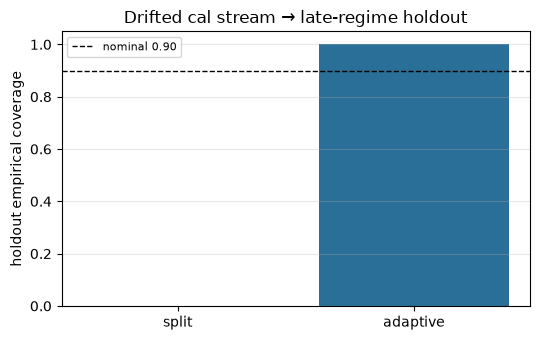

In [5]:
edge_index = sequence.edge_index
drift_model = make_member()
patch_zero_predict(drift_model)

# Match tests/test_conformal.py::test_adaptive_beats_split_under_drift
# (many easy scores so the batch 90% quantile stays small).
n_early = 95
n_late = 5
n_hold = 20
early = [
    constant_residual_sequence(residual=0.05, steps=1, edge_index=edge_index)
    for _ in range(n_early)
]
late = [
    constant_residual_sequence(residual=2.0, steps=1, edge_index=edge_index)
    for _ in range(n_late)
]
holdout = [
    constant_residual_sequence(residual=2.0, steps=1, edge_index=edge_index)
    for _ in range(n_hold)
]
drifted_cal = early + late

gamma = 0.5
split_drift = ConformalKoopmanUQ(drift_model, method="split")
adapt_drift = ConformalKoopmanUQ(drift_model, method="adaptive", gamma=gamma)
split_drift.calibrate(drifted_cal, steps=1, alpha=0.1)
adapt_drift.calibrate(drifted_cal, steps=1, alpha=0.1)

split_covs = []
adapt_covs = []
for seq in holdout:
    origin = seq[0]
    targ = list(seq[1:2])
    split_covs.append(
        empirical_coverage(
            targ, split_drift.predict_interval(origin, steps=1, level=0.9)
        )
    )
    adapt_covs.append(
        empirical_coverage(
            targ, adapt_drift.predict_interval(origin, steps=1, level=0.9)
        )
    )

split_q = float(split_drift.quantiles[0])
adapt_q = float(adapt_drift.quantiles[0])
split_cov = float(np.mean(split_covs))
adapt_cov = float(np.mean(adapt_covs))
print(f"ACI gamma={gamma}")
print(f"split  q={split_q:.3f}  holdout_coverage={split_cov:.3f}")
print(f"adapt  q={adapt_q:.3f}  holdout_coverage={adapt_cov:.3f}")
assert adapt_q > split_q, "ACI should inflate above the batch split quantile"
assert adapt_cov > split_cov, "ACI should improve late-regime holdout coverage"

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.bar(
    ["split", "adaptive"],
    [split_cov, adapt_cov],
    color=["#6c757d", "#2a6f97"],
)
ax.axhline(0.9, color="k", ls="--", lw=1, label="nominal 0.90")
ax.set_ylabel("holdout empirical coverage")
ax.set_title("Drifted cal stream → late-regime holdout")
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## Results: coverage vs nominal and sharpness

For each α we recalibrate **split** conformal on the same cal windows. Look for
**wider** intervals as α decreases (higher nominal coverage). Ensemble and
latent-Gaussian are reported at level 0.9 only (they are not distribution-free
and do not take α the same way). The dashed line marks the 0.90 reference used
for those heuristic methods; conformal bars should be judged against their own
nominal column in the table. Entrywise coverage on a **single** test origin can
undershoot that nominal when scores are temporally dependent and the holdout is
small — treat the table as an empirical snapshot, not a finite-sample guarantee.


label               alpha  nominal  coverage     width
split α=0.05         0.05     0.95     0.958    0.8378
split α=0.1          0.10     0.90     0.854    0.7761
split α=0.2          0.20     0.80     0.708    0.7040
ensemble             0.10     0.90     0.729    0.2787
latent_gaussian      0.10     0.90     1.000    4.2282


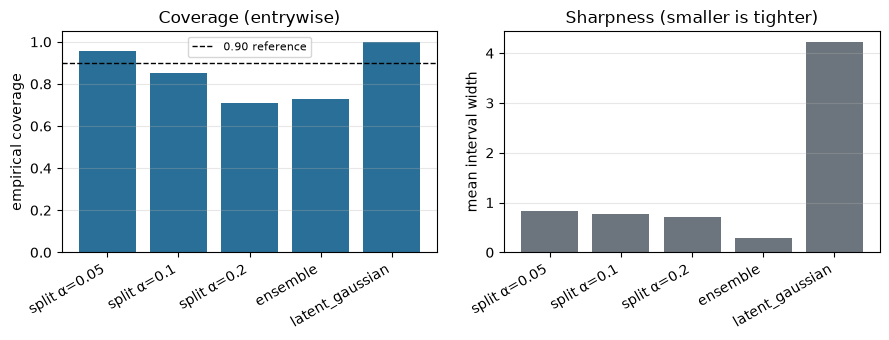

In [6]:
rows = []
for alpha in ALPHAS:
    level = 1.0 - alpha
    uq = ConformalKoopmanUQ(point_model, method="split", score="aggregate")
    uq.calibrate(cal_windows, steps=HORIZON, alpha=alpha)
    interval = uq.predict_interval(initial, steps=HORIZON, level=level)
    rows.append(
        {
            "method": "conformal_split",
            "label": f"split α={alpha:g}",
            "alpha": alpha,
            "nominal": level,
            "coverage": empirical_coverage(targets, interval),
            "mean_width": mean_interval_width(interval),
        }
    )

ens_level = 0.9
ens_interval = ensemble.predict_interval(initial, steps=HORIZON, level=ens_level)
rows.append(
    {
        "method": "ensemble",
        "label": "ensemble",
        "alpha": 1.0 - ens_level,
        "nominal": ens_level,
        "coverage": empirical_coverage(targets, ens_interval),
        "mean_width": mean_interval_width(ens_interval),
    }
)

gauss = LatentGaussianKoopmanUQ(
    point_model,
    process_noise=1e-3,
    initial_covariance=1.0,
    n_samples=N_SAMPLES,
)
gauss_interval = gauss.predict_interval(
    initial,
    steps=HORIZON,
    level=ens_level,
    generator=torch.Generator().manual_seed(SEED),
)
rows.append(
    {
        "method": "latent_gaussian",
        "label": "latent_gaussian",
        "alpha": 1.0 - ens_level,
        "nominal": ens_level,
        "coverage": empirical_coverage(targets, gauss_interval),
        "mean_width": mean_interval_width(gauss_interval),
    }
)

print(f"{'label':18s}  {'alpha':>5s}  {'nominal':>7s}  {'coverage':>8s}  {'width':>8s}")
for row in rows:
    print(
        f"{row['label']:18s}  {row['alpha']:5.2f}  {row['nominal']:7.2f}  "
        f"{row['coverage']:8.3f}  {row['mean_width']:8.4f}"
    )

# Sanity: with enough cal windows, smaller α should not shrink mean width.
conf_rows = [row for row in rows if row["method"] == "conformal_split"]
if len(conf_rows) >= 2:
    widths_by_alpha = sorted(
        (row["alpha"], row["mean_width"]) for row in conf_rows
    )
    for (a0, w0), (a1, w1) in zip(widths_by_alpha, widths_by_alpha[1:]):
        assert w0 + 1e-9 >= w1, (
            f"expected width nonincreasing in α; got α={a0}→{w0}, α={a1}→{w1}"
        )

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
labels = [row["label"] for row in rows]
axes[0].bar(range(len(rows)), [row["coverage"] for row in rows], color="#2a6f97")
axes[0].axhline(0.9, color="k", ls="--", lw=1, label="0.90 reference")
axes[0].set_xticks(range(len(rows)))
axes[0].set_xticklabels(labels, rotation=30, ha="right")
axes[0].set_ylabel("empirical coverage")
axes[0].set_title("Coverage (entrywise)")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(range(len(rows)), [row["mean_width"] for row in rows], color="#6c757d")
axes[1].set_xticks(range(len(rows)))
axes[1].set_xticklabels(labels, rotation=30, ha="right")
axes[1].set_ylabel("mean interval width")
axes[1].set_title("Sharpness (smaller is tighter)")
axes[1].grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()


## Interpretation

- **Exchangeability.** Split conformal's finite-sample guarantee needs
  exchangeable nonconformity scores. Chronological graph forecasts usually
  break that — report empirical coverage and prefer ACI when residuals drift
  *and* the ACI step size is large enough to track the late regime (here
  `gamma=0.5` with a short hard burst).
- **Sharpness vs coverage.** With enough calibration windows, smaller α
  (higher nominal coverage) widens bands. If \(n_{\mathrm{cal}}\) is tiny, the
  discrete split order statistic can collapse across several α values — the
  table above should show distinct widths.
- **Heuristic UQ.** Ensemble intervals can be sharp yet under-cover; latent-
  Gaussian bands can over-cover with large width. Do not rank methods by width
  alone. Probabilistic Koopman models such as \(K^2\)VAE (Wu et al., 2025)
  remain complementary rather than distribution-free substitutes.
- **Calibration data.** Conformal needs a held-out cal set that never touches
  the final test origin. Reusing train residuals understates uncertainty.
- **MPC link.** Conformal half-widths can tighten constraints
  (`constraint_tightening=` on `KoopmanMPC`) — see design §1.5 / notebook 31.


## Takeaways

- Use `ConformalKoopmanUQ(method="split")` when residuals look roughly
  exchangeable and you can spare a calibration stream with enough windows for
  the α levels you care about.
- Prefer `method="adaptive"` (ACI) when the cal stream itself drifts; choose
  `gamma` large enough that the quantile can reach the late residual scale
  before holdout (too-small `gamma` can leave ACI narrower than split).
- Keep ensemble / latent-Gaussian (and related probabilistic Koopman UQ) for
  epistemic / latent-noise stories (notebook 21); use conformal when you want
  distribution-free bands with an explicit α.
- Never claim exact \(1-\alpha\) coverage for multi-step Koopman forecasts
  without stating exchangeability / ACI assumptions.


## Further reading

- API: `koopman_graph.uq.ConformalKoopmanUQ`, `empirical_coverage`,
  `EnsembleGraphKoopmanModel`, `LatentGaussianKoopmanUQ`
- Related notebooks: [`21_uncertainty_quantification.ipynb`](21_uncertainty_quantification.ipynb),
  [`31_koopman_mpc_control.ipynb`](31_koopman_mpc_control.ipynb)
- Architecture: Sphinx `architecture` — UQ capability map
- Citations (`paper.bib`): `Vovk2005`, `Lei2018`, `GibbsCandes2021`,
  `Liang2025ConformalKoopman`, `Hirano2026ConformalKoopman`, `Chee2024`,
  `Wu2025K2VAE`
